# Phase 1: Exploratory Data Analysis

This notebook performs normal EDA including identifying categorical vs continuous features, and plotting their distributions.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic parameters
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Load the transactions data
data_path = '../../data/original/transactions.csv'
df = pd.read_csv(data_path)
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (100222, 55)


,row_index,Date,Time,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,...,tx_count_10,tx_count_30,amount_zscore,transmode_A,transmode_B,transmode_E,transmode_F,transmode_J,transmode_P,transmode_Z
0,0,2022-10-07,10:35:19,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,...,1.0,1.0,-0.293518,1,0,0,0,0,0,0
1,1,2022-10-07,10:35:20,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,...,1.0,1.0,-0.106146,0,0,0,1,0,0,0
2,2,2022-10-07,10:35:20,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,...,1.0,1.0,0.235230,0,0,1,0,0,0,0
3,3,2022-10-07,10:35:21,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,...,1.0,1.0,0.135250,0,0,0,0,0,1,0
4,4,2022-10-07,10:35:21,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,...,1.0,1.0,-0.348734,1,0,0,0,0,0,0


: 

In [4]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Total Features: {len(df.columns)}")
print(f"Number of Categorical Features: {len(categorical_cols)}")
print(f"Number of Numerical Features: {len(numerical_cols)}")

print("\nCategorical Features:")
for col in categorical_cols:
    print(f" - {col}")

print("\nNumerical Features:")
for col in numerical_cols:
    print(f" - {col}")

Total Features: 55
Number of Categorical Features: 20
Number of Numerical Features: 35

Categorical Features:
 - Date
 - Time
 - Payment_currency
 - Received_currency
 - Sender_bank_location
 - Receiver_bank_location
 - Payment_type
 - transmode_code
 - sender_institution
 - sender_branch
 - sender_account_number
 - sender_account_type
 - sender_risk_grade
 - sender_opened
 - sender_city
 - receiver_institution
 - receiver_branch
 - receiver_account_number
 - receiver_account_type
 - date_transaction

Numerical Features:
 - row_index
 - Sender_account
 - Receiver_account
 - Amount
 - fx_rate_to_npr
 - amount_local_npr
 - sender_country_risk
 - receiver_country_risk
 - cross_border_flag
 - currency_mismatch
 - sender_is_person
 - sender_pep
 - sender_sanctions
 - sender_account_age_days
 - receiver_pep
 - receiver_sanctions
 - receiver_account_age_days
 - hour_of_day
 - day_of_week
 - is_weekend
 - month
 - log_amount
 - above_1M_NPR
 - above_10M_NPR
 - velocity_sum_10tx
 - tx_count_10


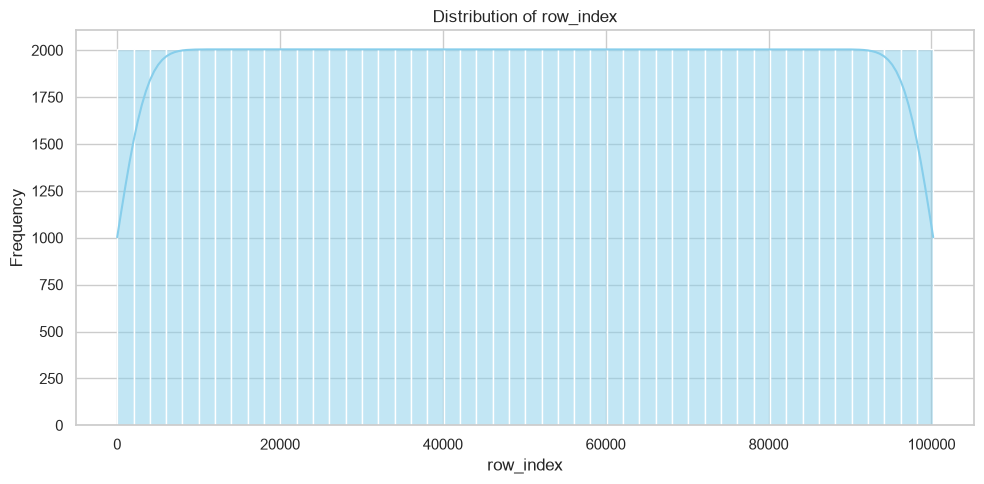

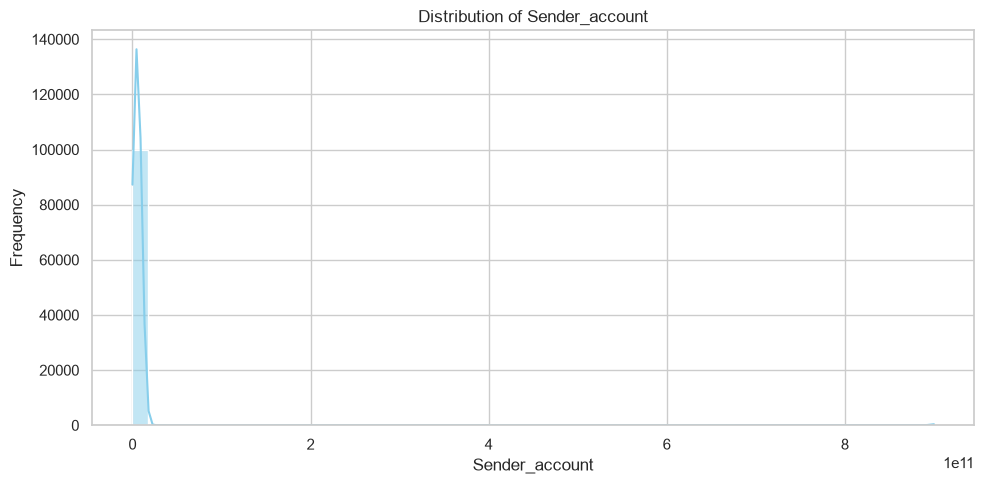

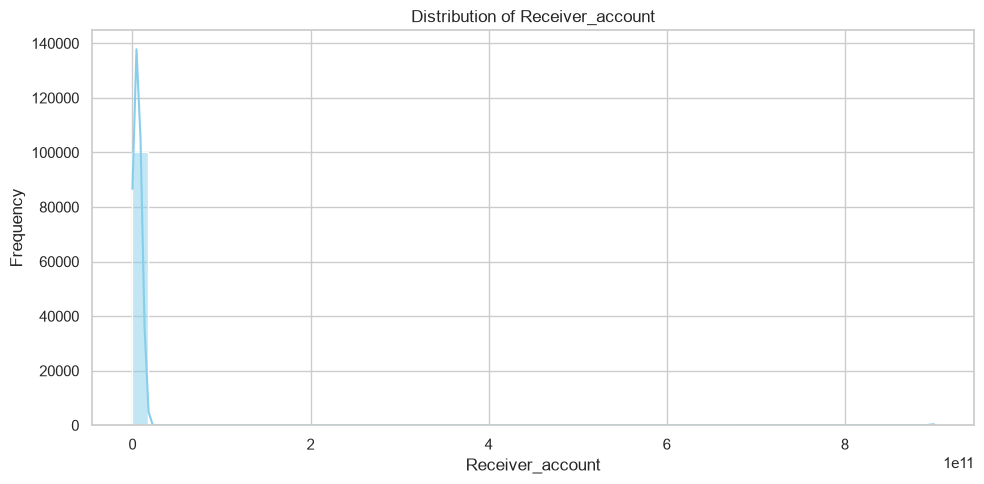

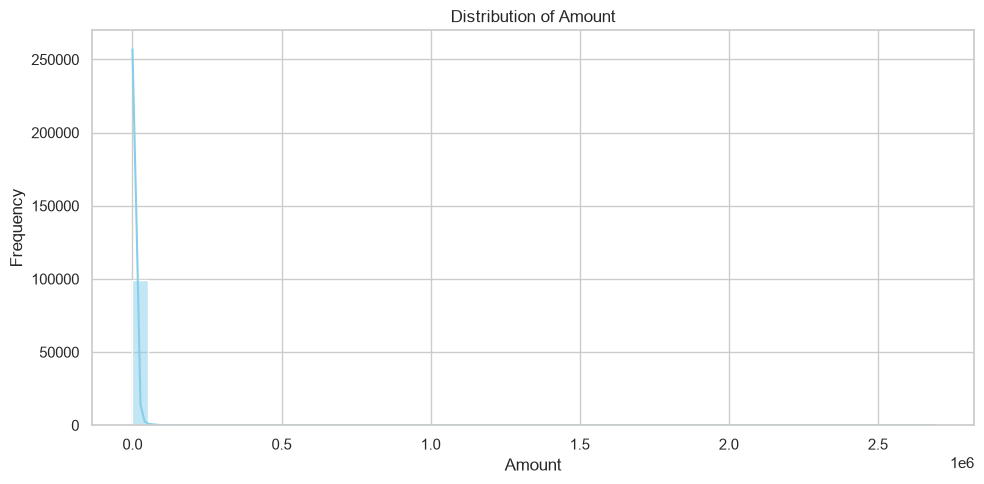

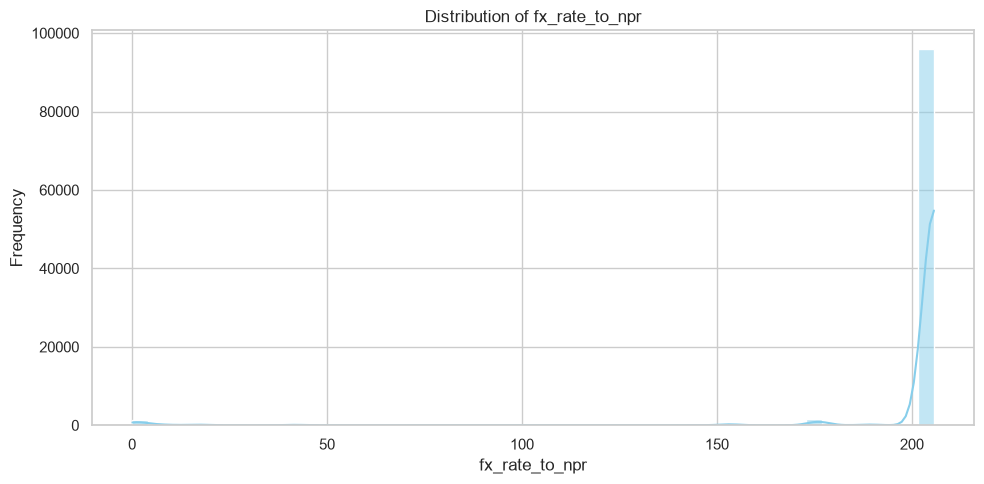

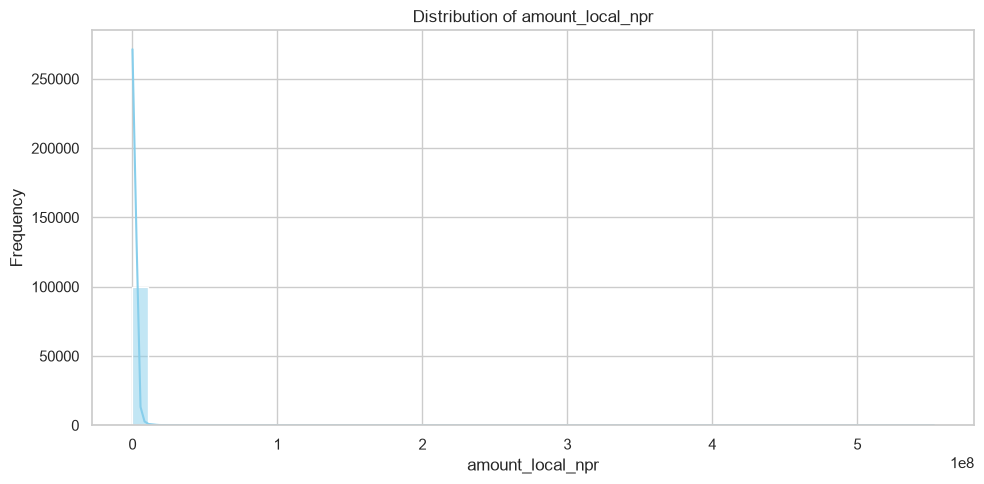

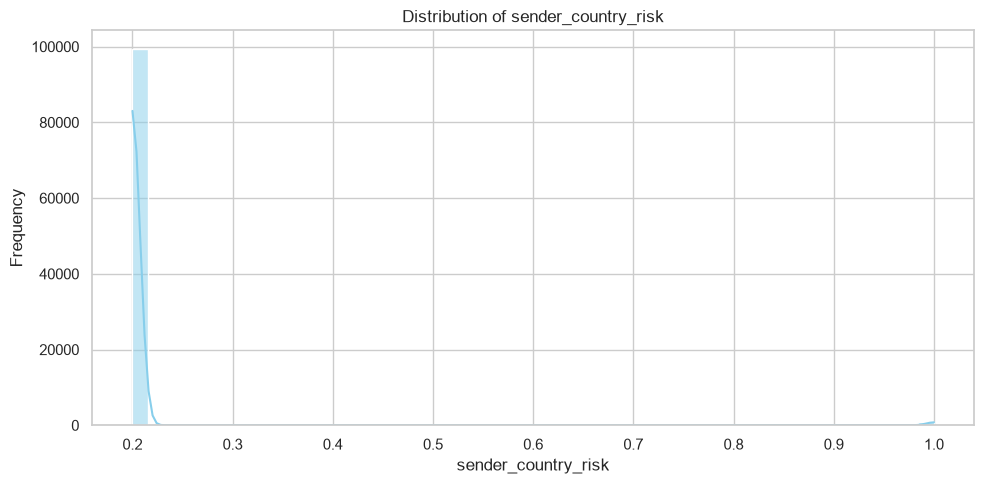

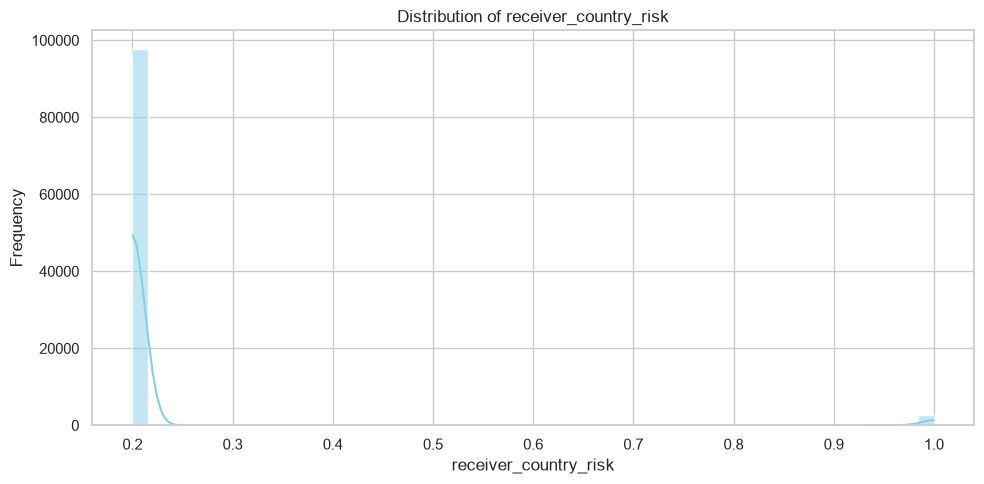

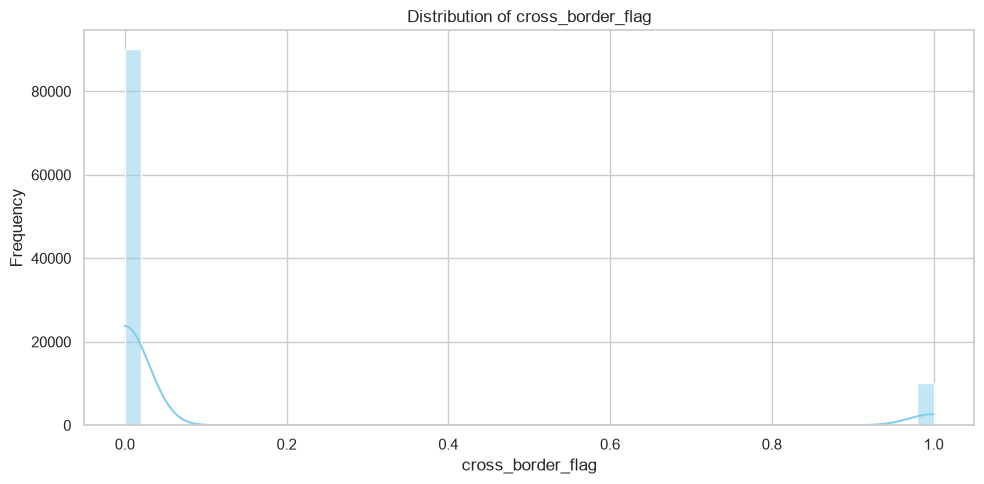

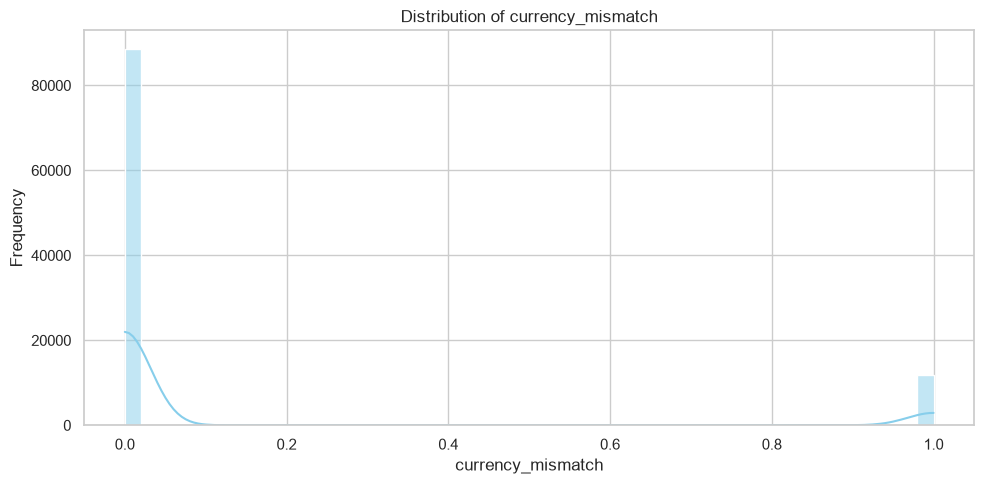

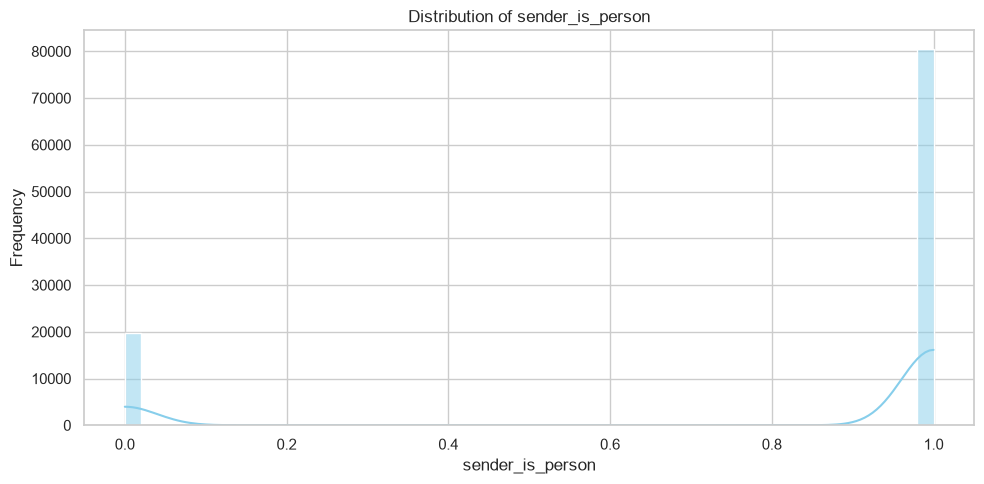

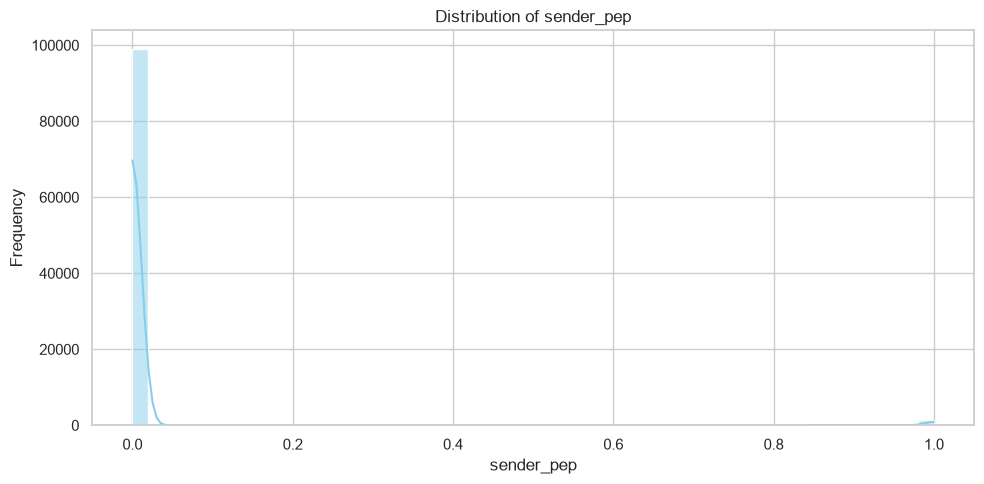

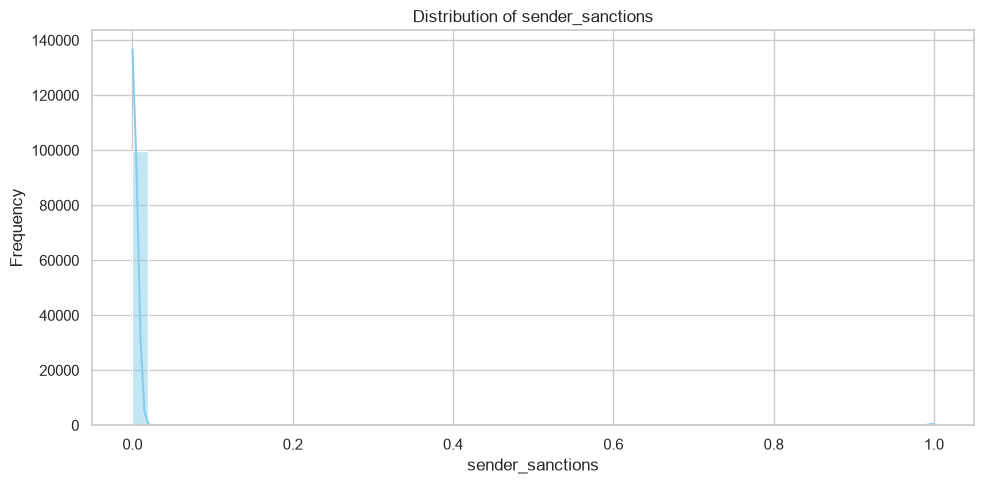

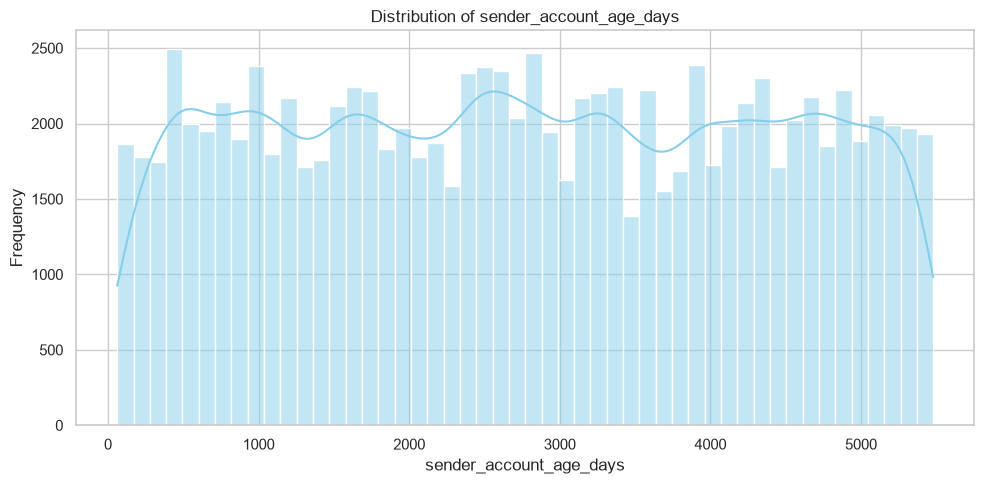

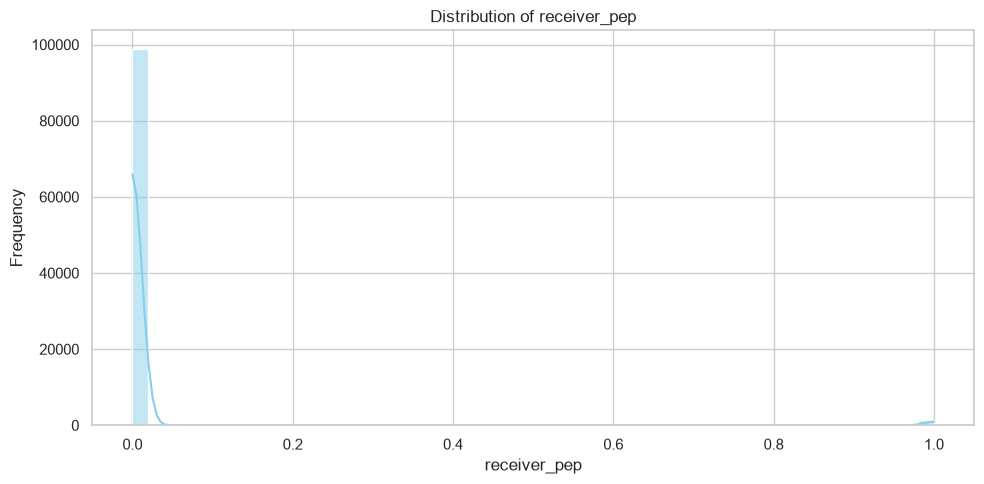

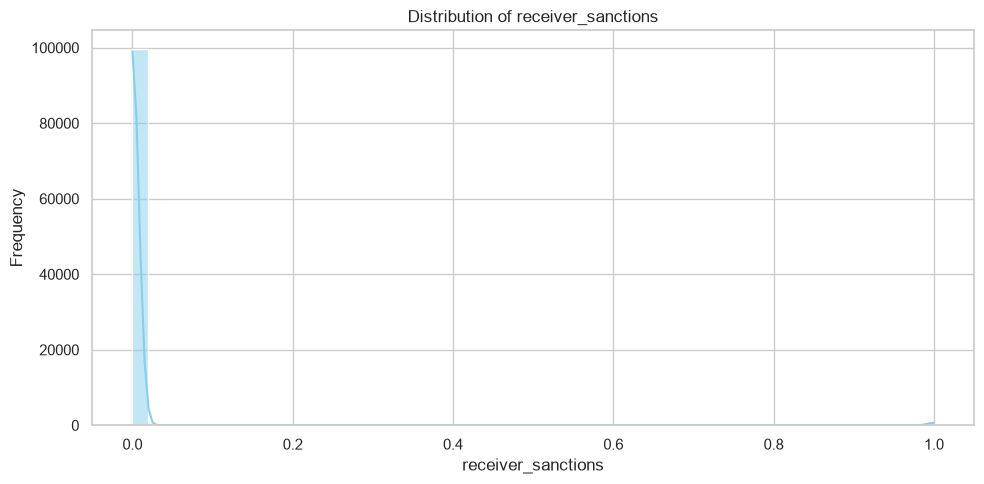

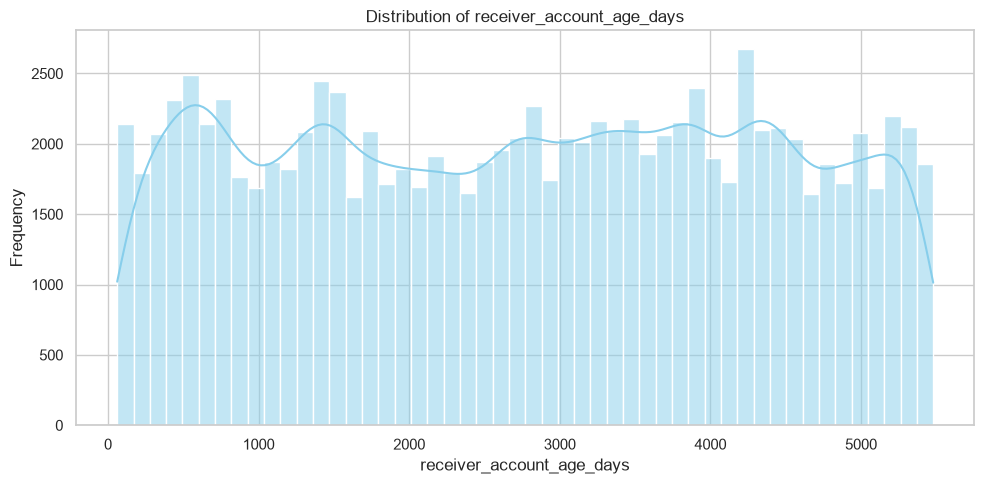

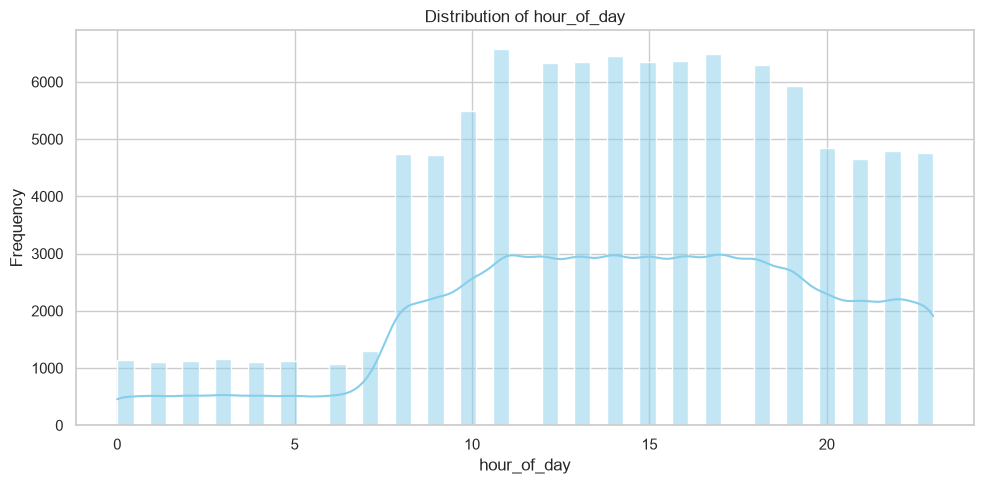

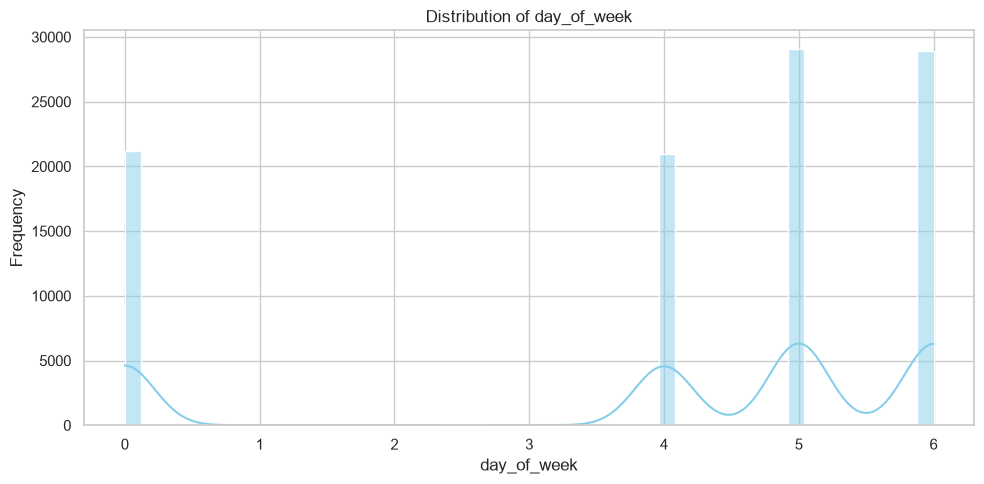

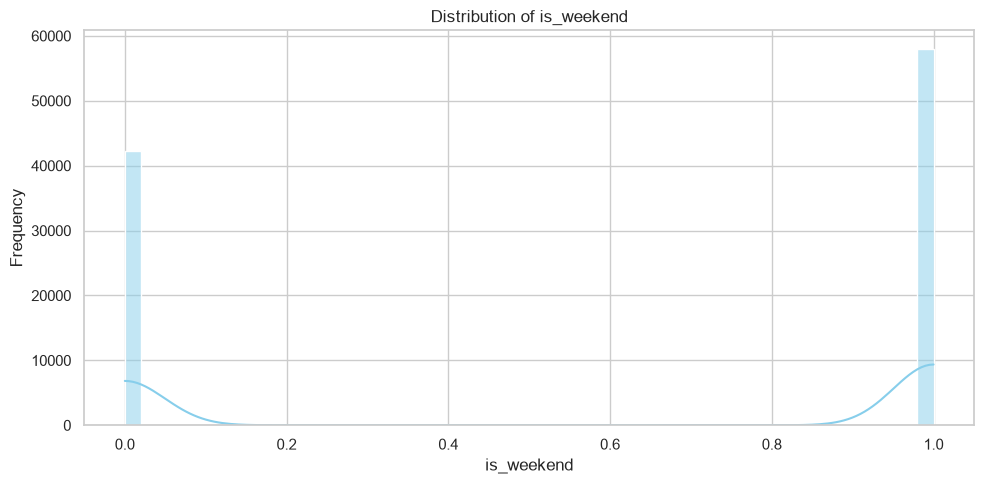

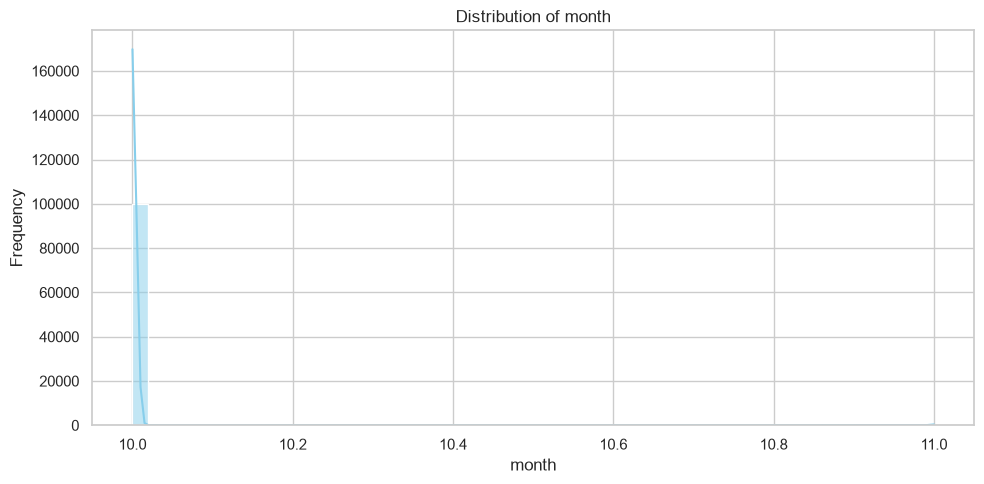

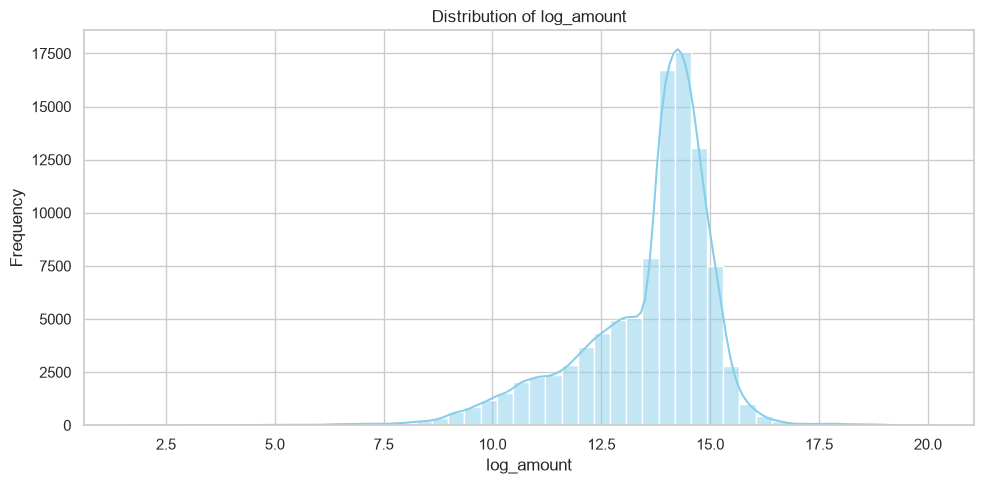

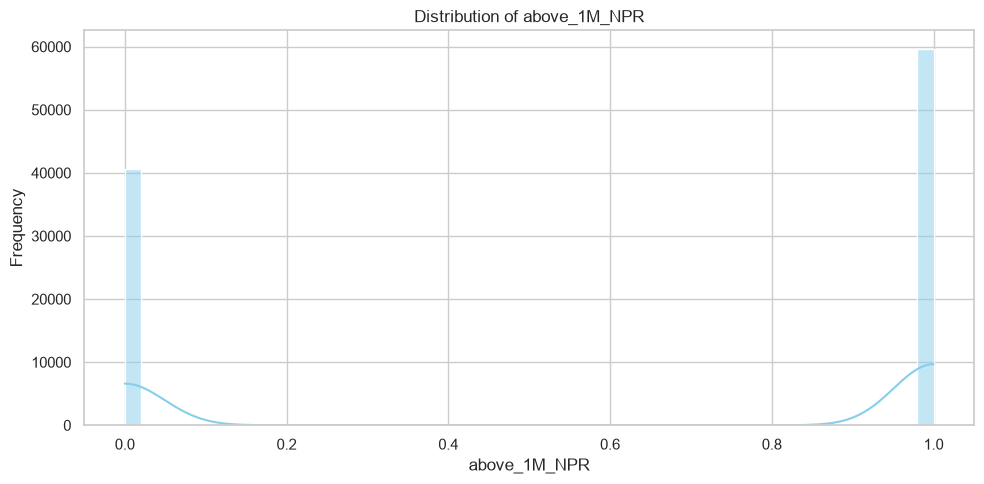

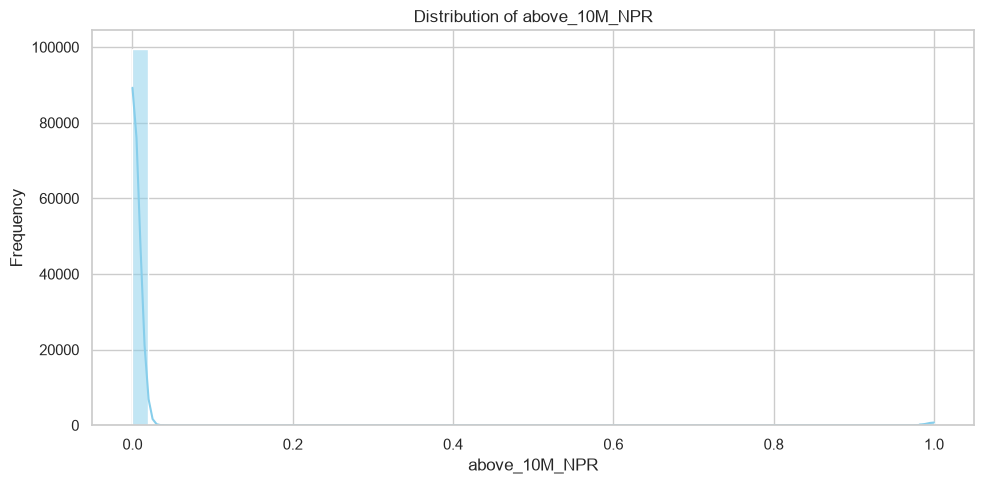

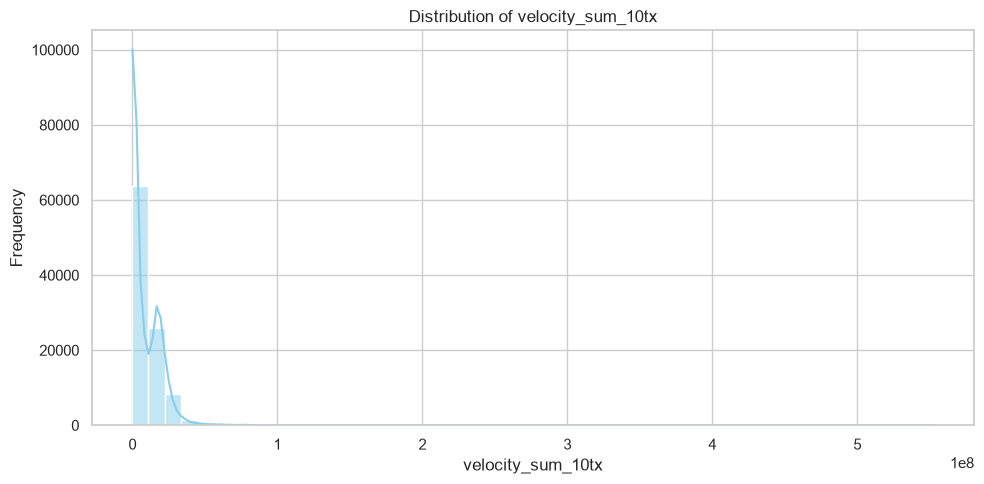

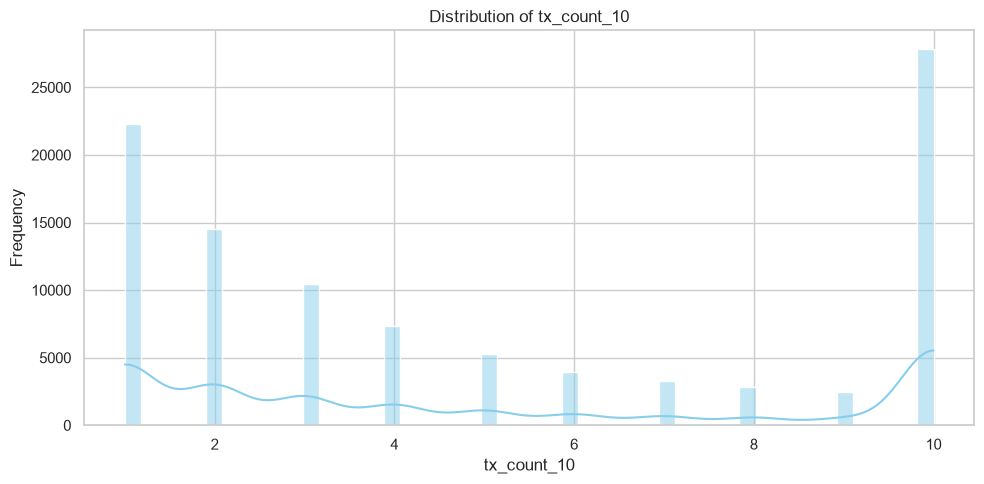

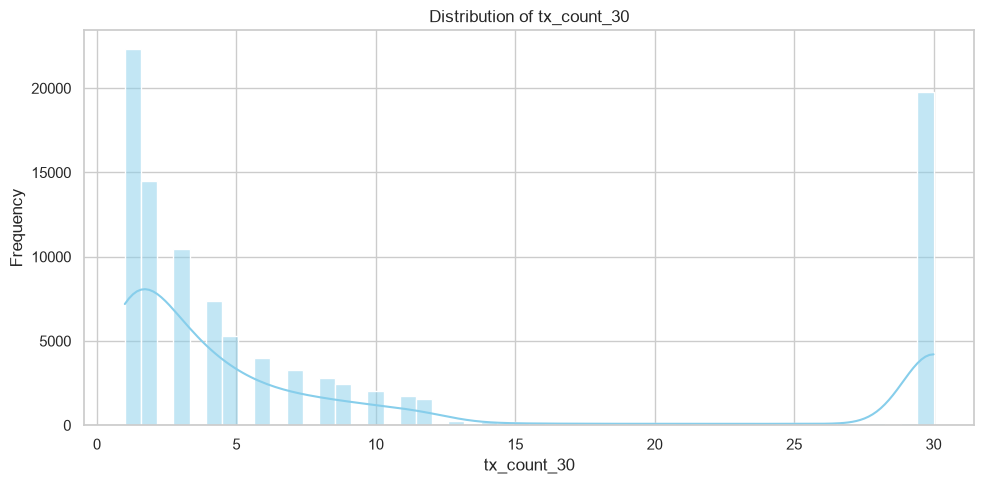

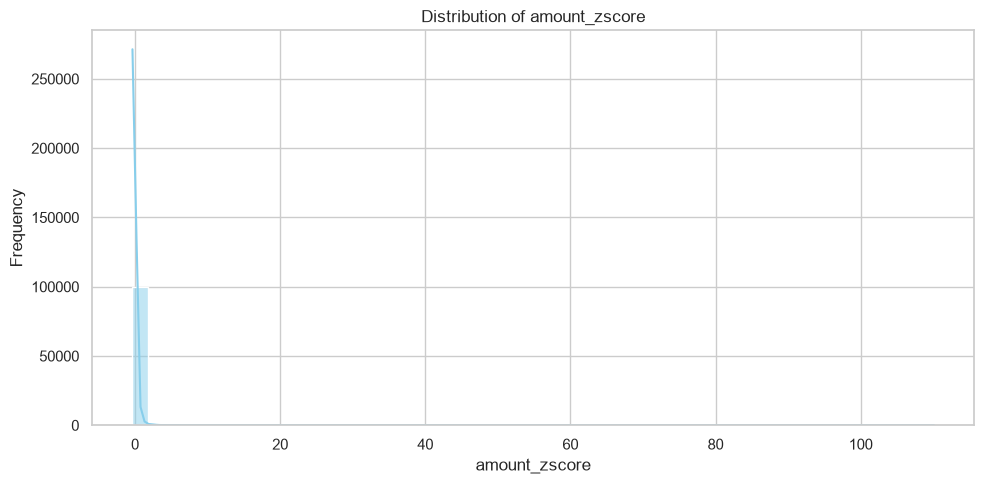

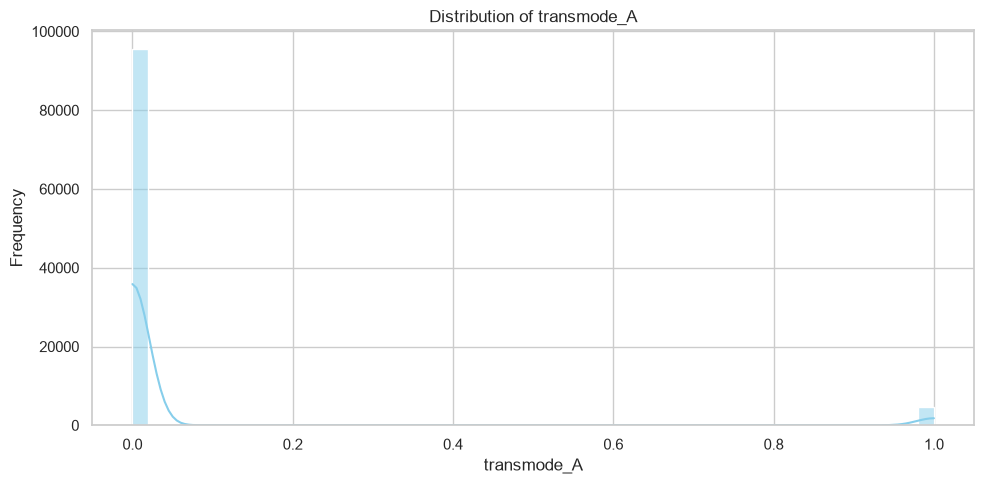

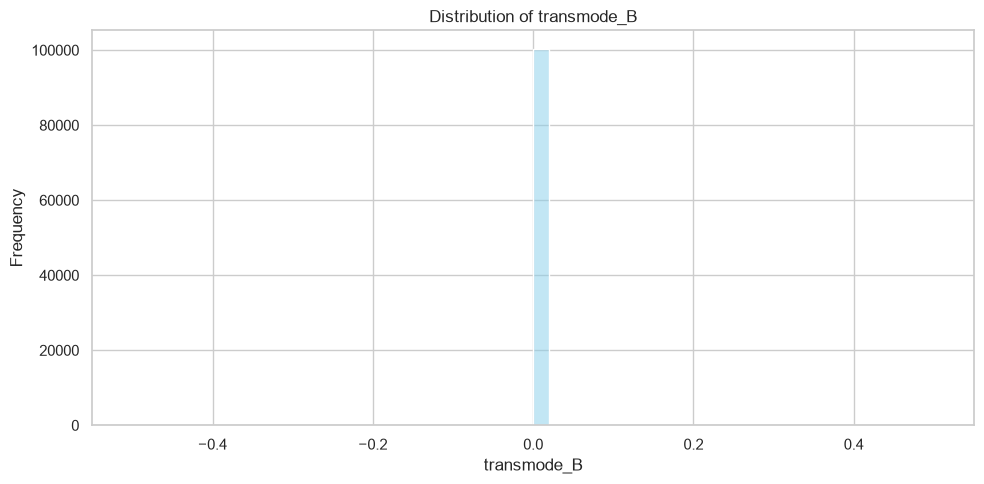

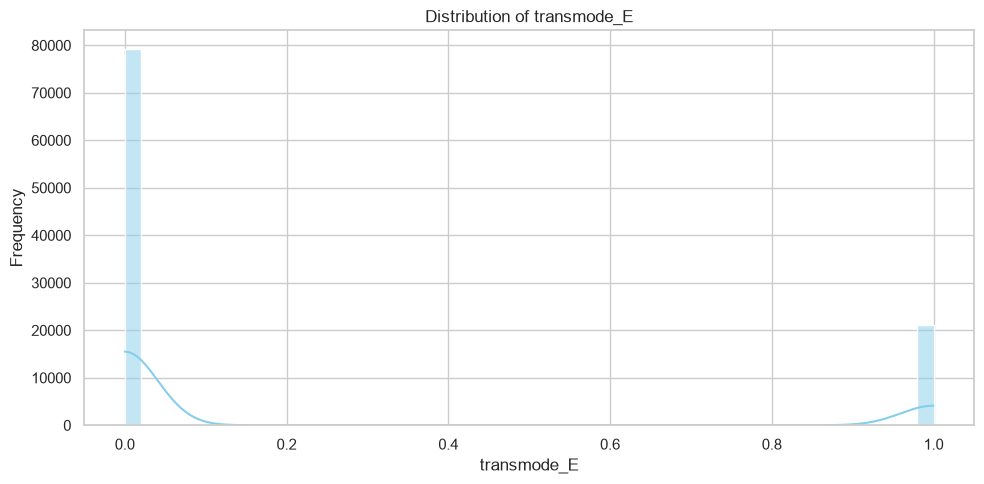

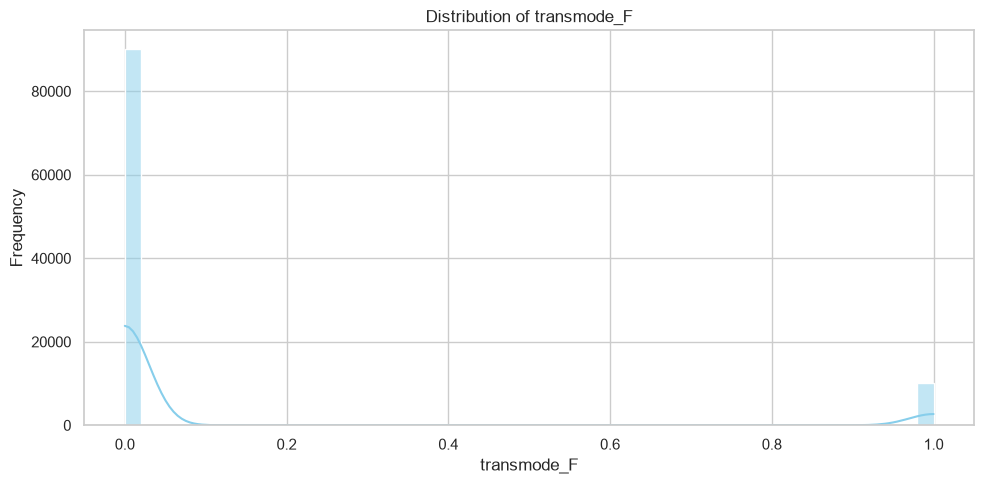

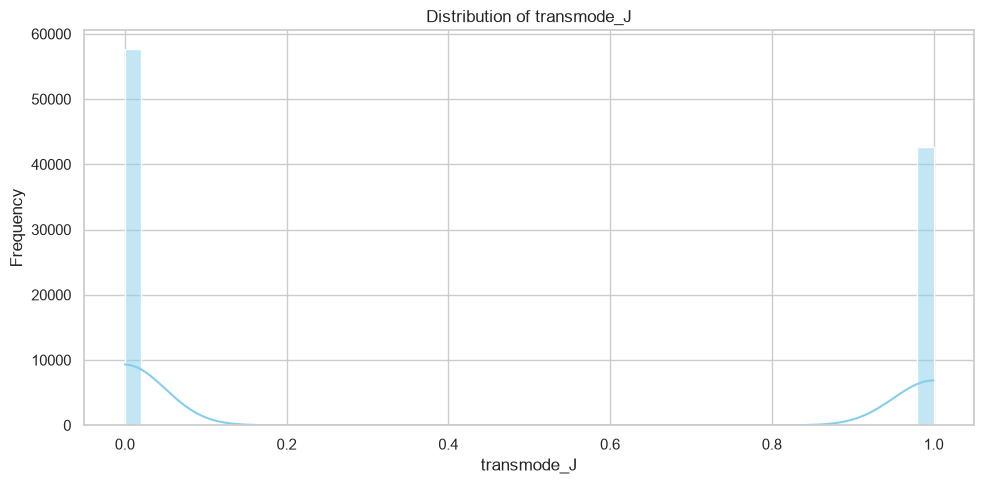

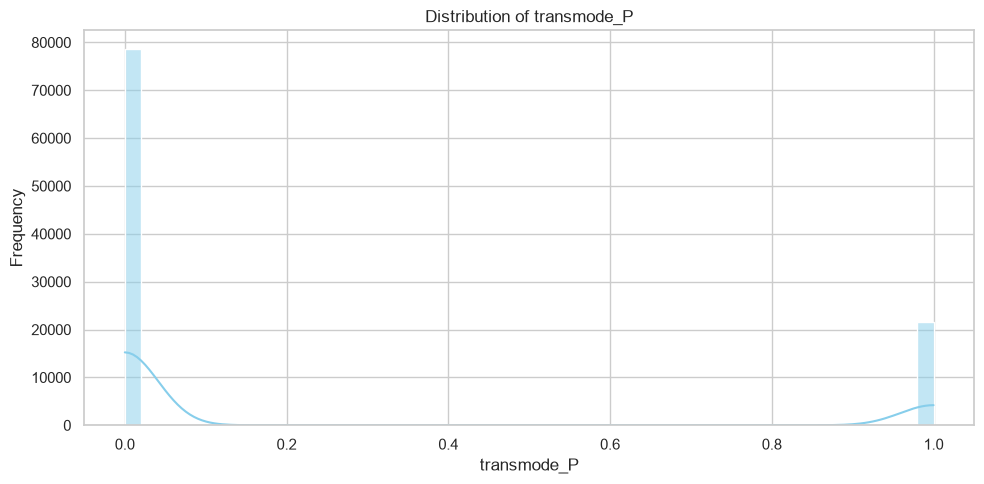

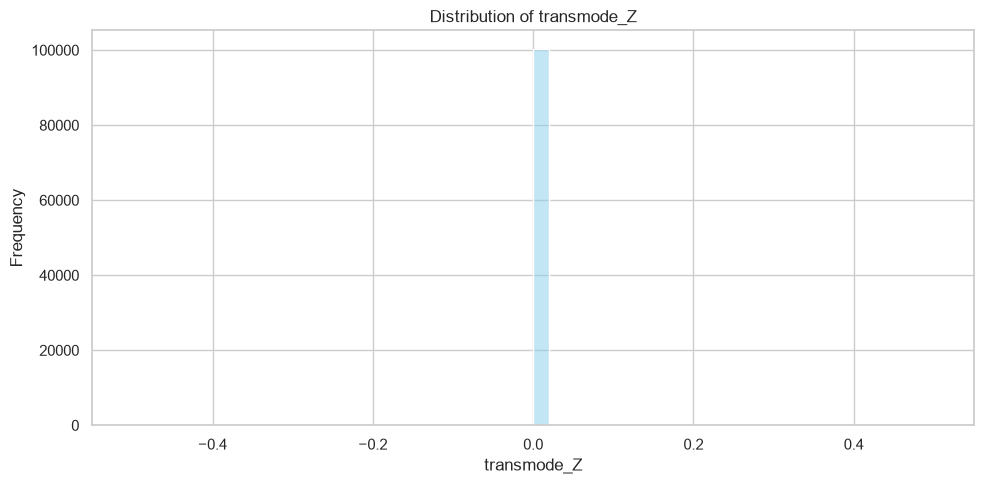

In [5]:
# Distribution Analysis for Numerical Features
for col in numerical_cols:
    # Skip columns that look like IDs or very large
    if df[col].nunique() > 1000 and 'id' in col.lower():
        print(f"Skipping {col} (looks like an ID)")
        continue
    
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col].dropna(), bins=50, kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

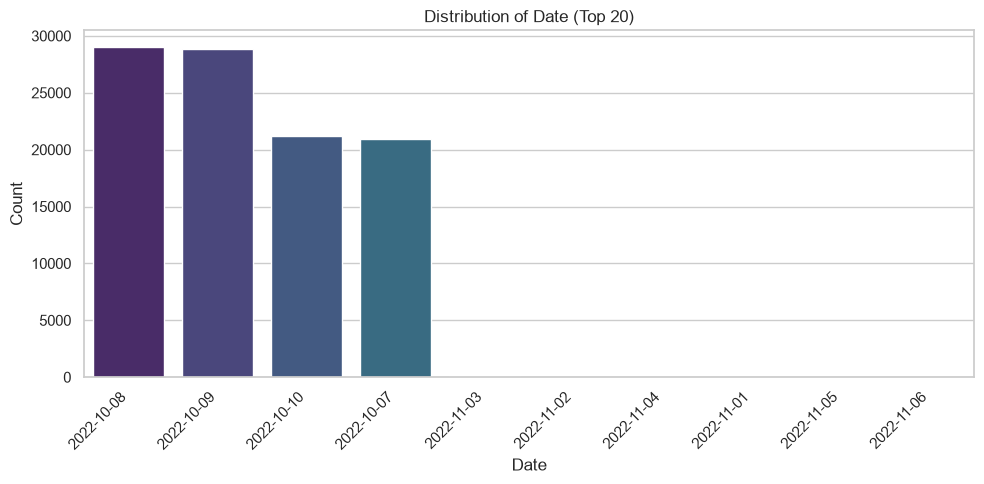

Skipping Time - too many unique values (53208)


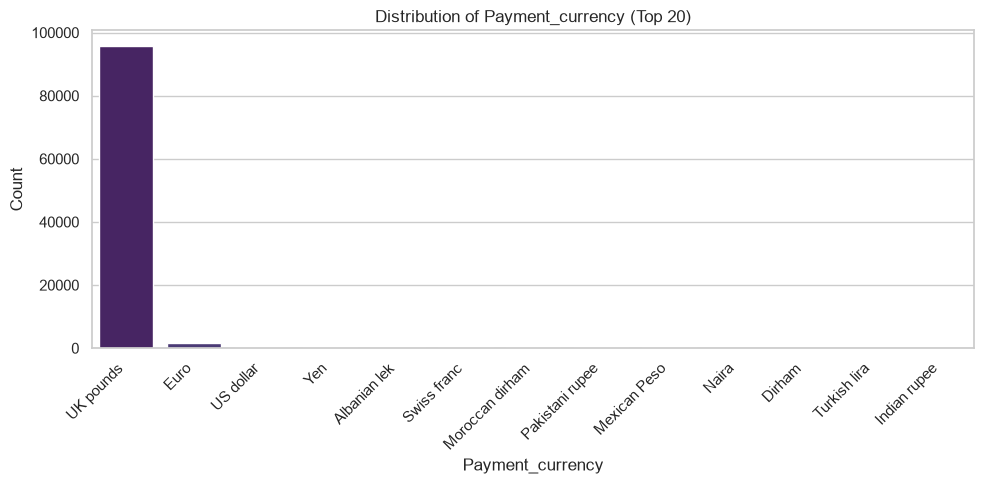

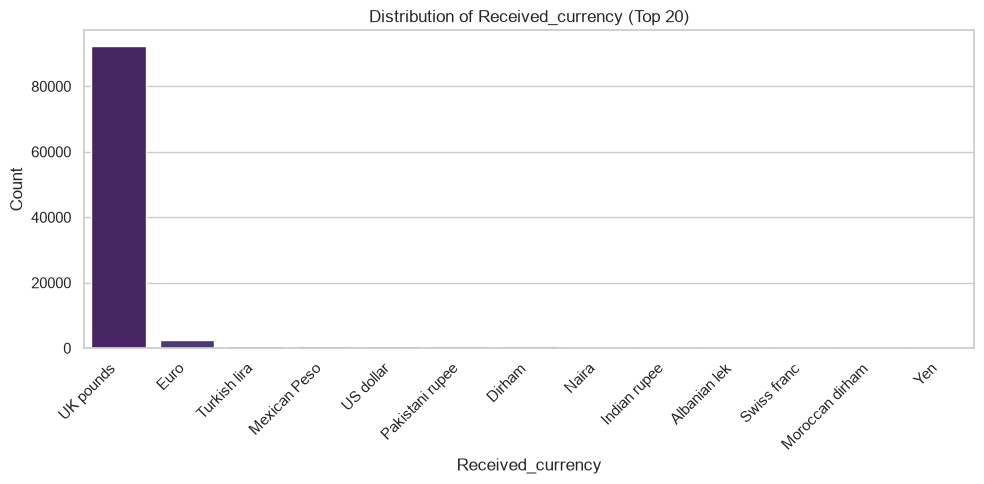

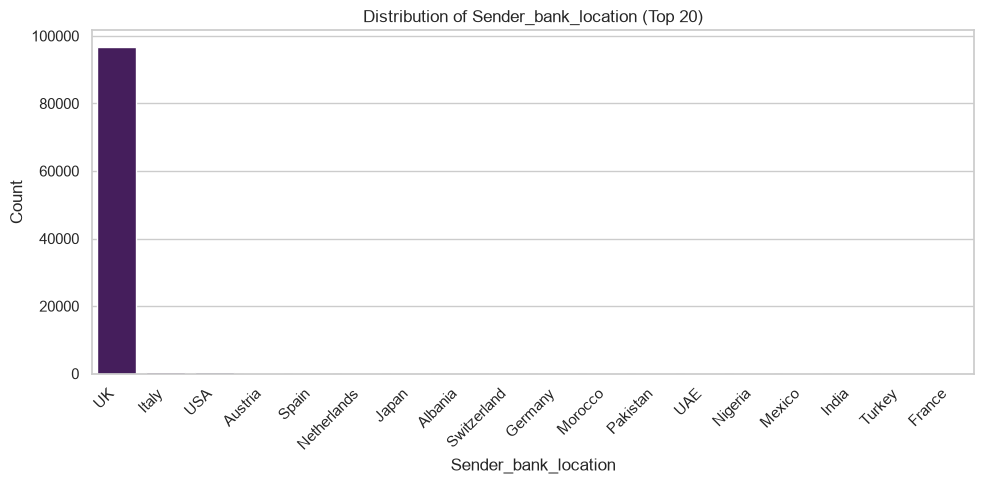

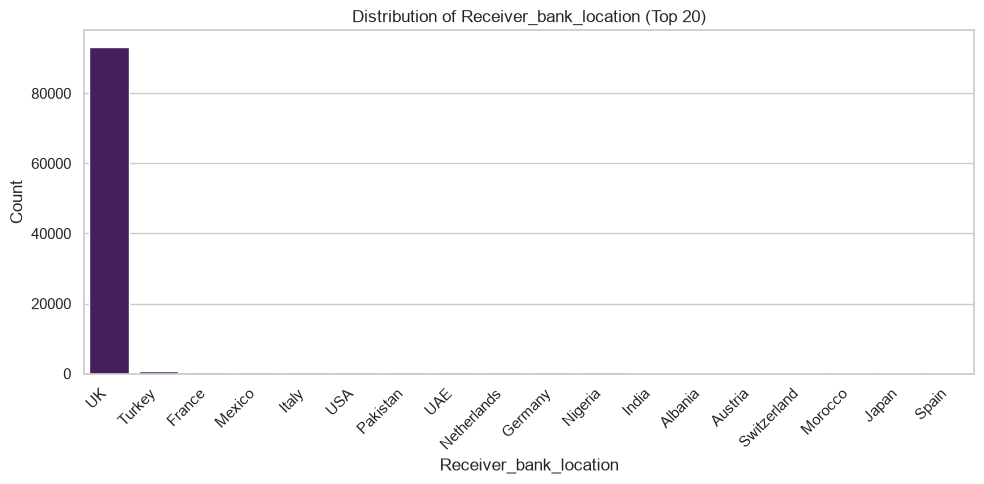

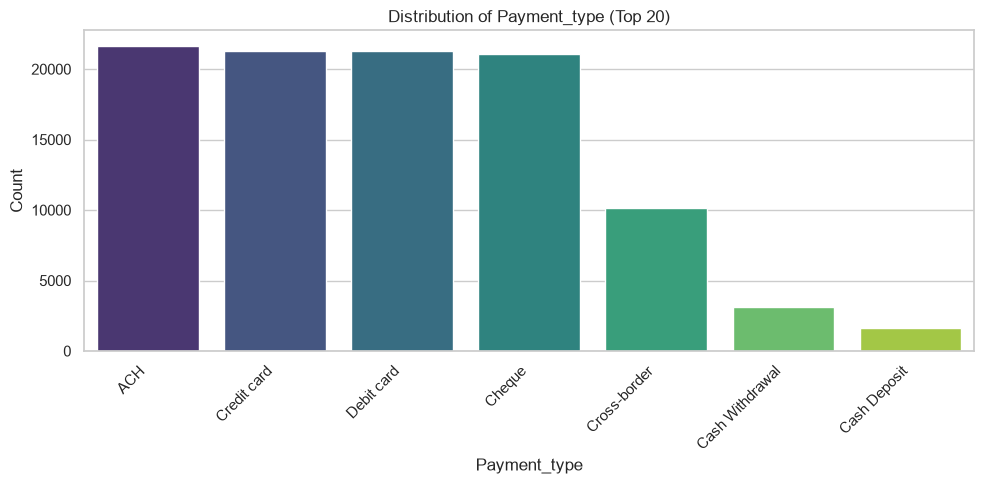

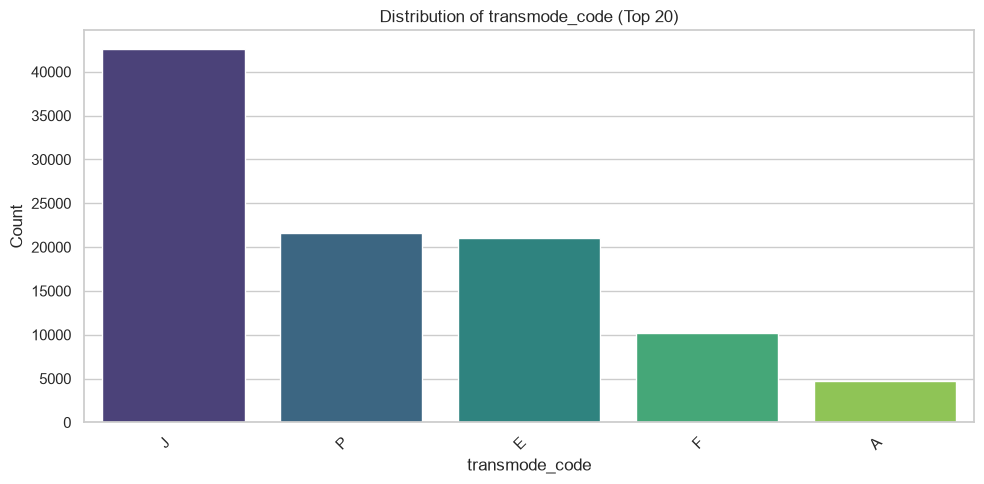

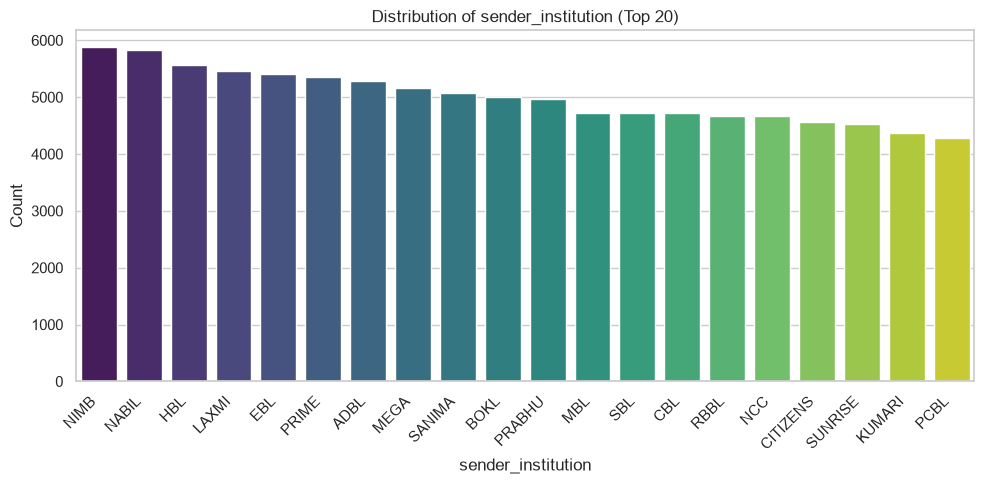

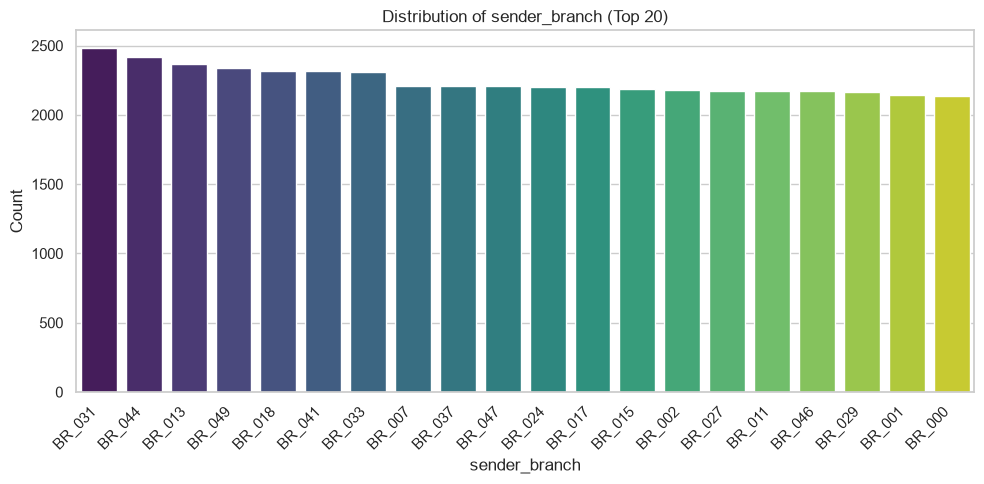

Skipping sender_account_number - too many unique values (22309)


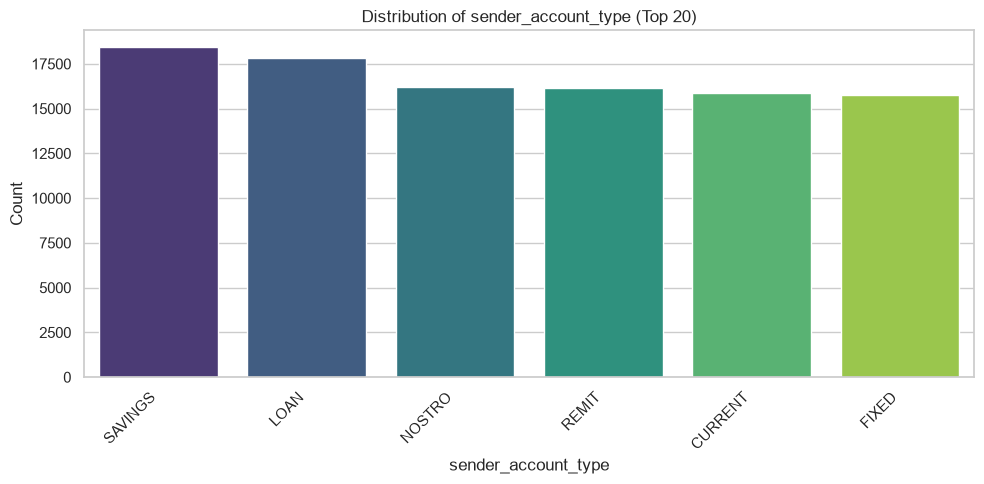

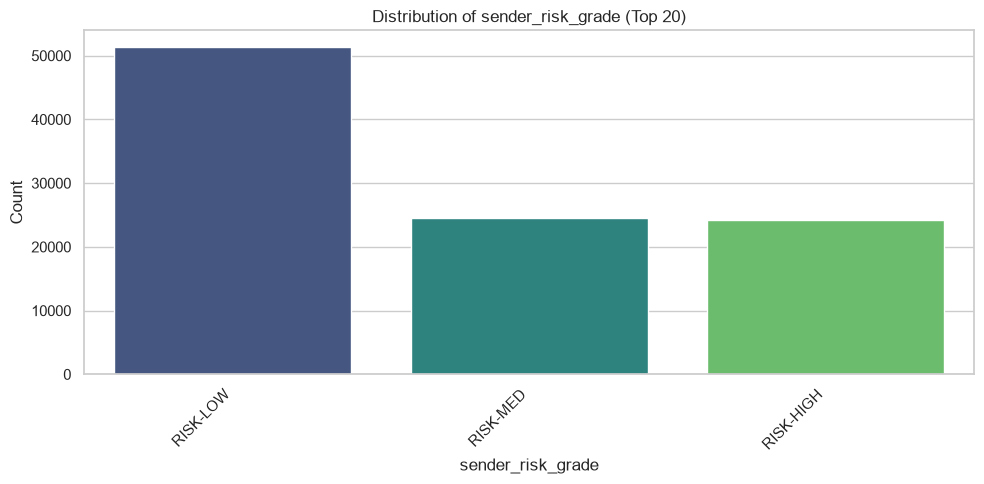

Skipping sender_opened - too many unique values (5342)


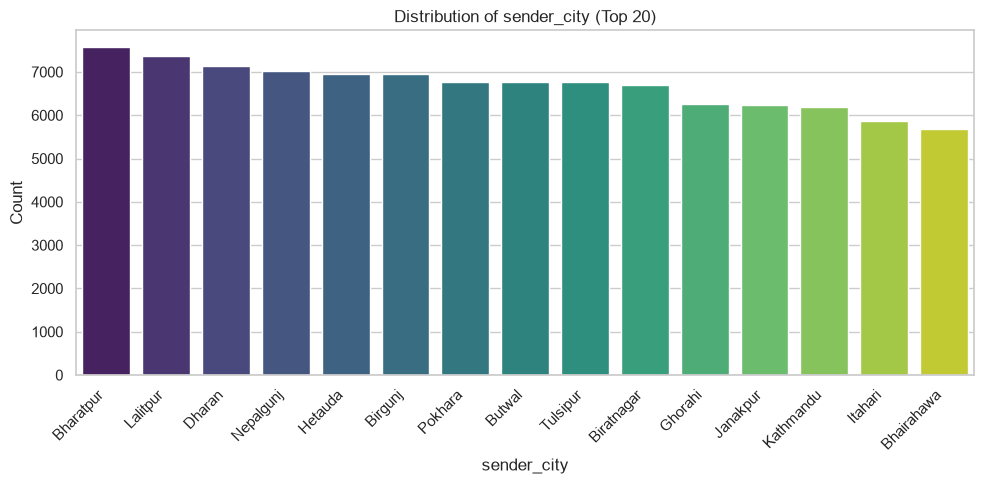

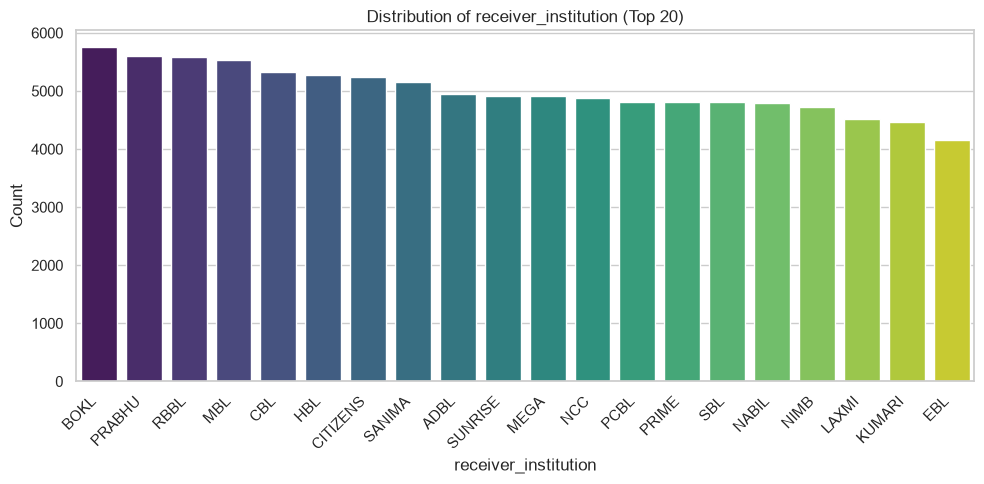

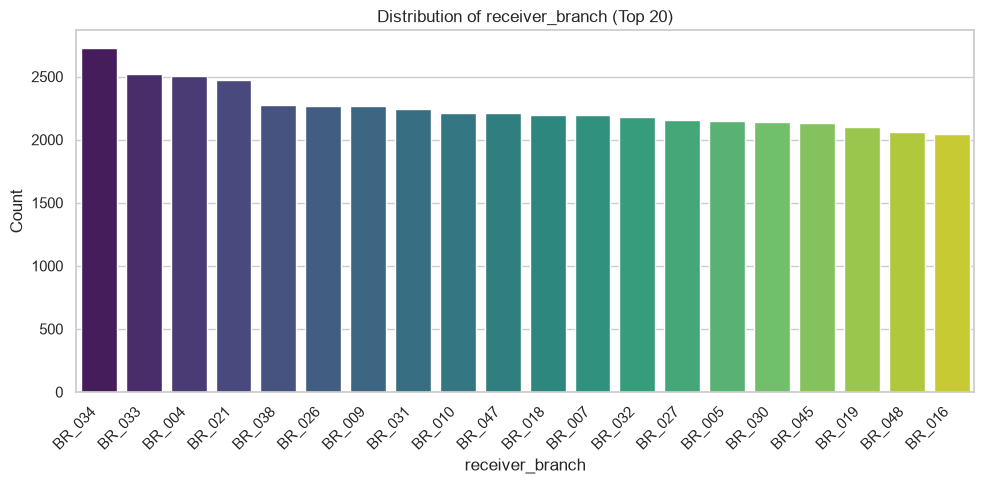

Skipping receiver_account_number - too many unique values (46586)


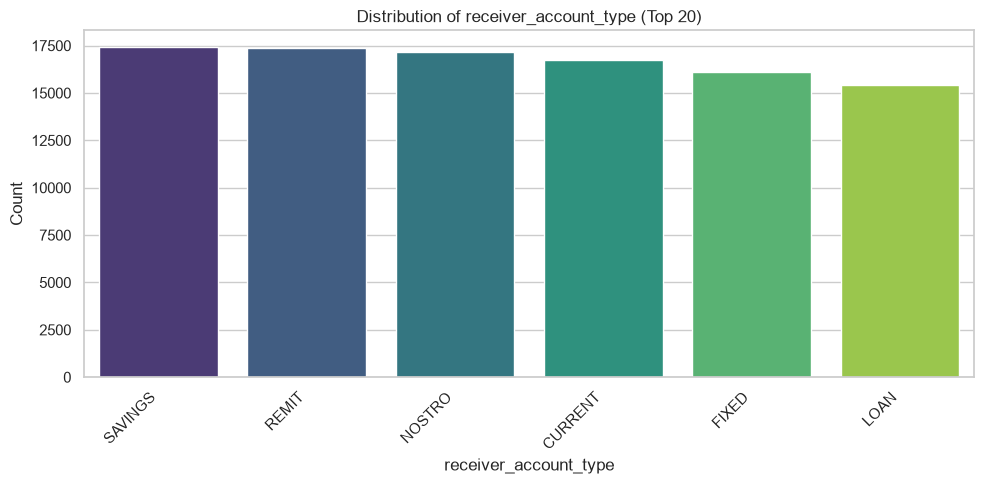

Skipping date_transaction - too many unique values (82296)


In [6]:
# Distribution Analysis for Categorical Features
for col in categorical_cols:
    unique_vals = df[col].nunique()
    if unique_vals > 50:
        print(f"Skipping {col} - too many unique values ({unique_vals})")
        continue
        
    plt.figure(figsize=(10, 5))
    val_counts = df[col].value_counts().head(20)  # Top 20 max
    sns.barplot(x=val_counts.index, y=val_counts.values, palette='viridis')
    plt.title(f'Distribution of {col} (Top 20)')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()